# Week-3: Supervised Learning - Classification Model
## Titanic Survival Prediction

**Task:** Binary classification - predict whether a passenger survived (1) or did not survive (0).

**Dataset:** Cleaned Titanic dataset from Week 2 preprocessing pipeline (891 rows × 24 features, fully numeric, no missing values).

**Models trained:**
| Model | Key characteristic |
|-------|-------------------|
| Logistic Regression | Linear decision boundary, interpretable coefficients |
| Decision Tree | Non-linear, rule-based splits, prone to overfitting |
| Random Forest | Ensemble of 100 trees, reduces variance via bagging |

**Evaluation metrics used:**
- **Accuracy** - overall correct predictions (misleading with class imbalance)
- **Precision** - of predicted survivors, how many actually survived
- **Recall** - of actual survivors, how many did the model catch
- **F1 Score** - harmonic mean of precision and recall (primary metric here)
- **ROC-AUC** - ability to rank survivors above non-survivors across all thresholds
- **Cross-Validation F1** - F1 averaged across 5 stratified folds (generalisability check)

> **Note on class imbalance:** 61.6% did not survive vs 38.4% survived. A naive model that always predicts "did not survive" would score 61.6% accuracy — so accuracy alone is not a reliable metric here. F1 score and ROC-AUC are more meaningful.

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             roc_curve, classification_report)
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('titanic_cleaned.csv')
print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df['Survived'].value_counts())
print(df['Survived'].value_counts(normalize=True).round(3))
df.head()

Dataset shape: (891, 25)

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,...,Title_Group_Officer,Title_Group_Royalty,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,-0.557481,0.432793,-0.473674,-0.820552,0.059160,0,-0.806026,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,0.648840,0.432793,-0.473674,2.031623,0.059160,0,1.237601,...,0,0,0,1,0,0,0,0,0,0
2,1,3,1,-0.255901,-0.474545,-0.473674,-0.787578,-0.560975,1,-0.505001,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,0.422655,0.432793,-0.473674,1.419297,0.059160,0,0.798860,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,0.422655,-0.474545,-0.473674,-0.781471,-0.560975,1,-0.496250,...,0,0,0,0,0,0,0,0,0,1


## 2. Train / Test Split

We split 80% for training and 20% for testing. `stratify=y` ensures both splits maintain the same 61.6/38.4 class ratio — without this, a random split could accidentally give the test set a very different class balance, making evaluation unreliable.

In [3]:
X = df.drop(columns='Survived')
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows  (survived rate: {y_train.mean():.1%})")
print(f"Test set:      {X_test.shape[0]} rows  (survived rate: {y_test.mean():.1%})")
print(f"\nFeatures used: {X.shape[1]}")

Training set:  712 rows  (survived rate: 38.3%)
Test set:      179 rows  (survived rate: 38.5%)

Features used: 24


## 3. Train All Three Models

### Model 1: Logistic Regression
A linear model that learns a weighted combination of features and passes it through a sigmoid function to output a survival probability. Interpretable via its coefficients — each coefficient tells you directly how much that feature shifts the log-odds of survival. `max_iter=1000` ensures convergence.

### Model 2: Decision Tree
Recursively splits the data on the feature that best separates survivors from non-survivors (measured by Gini impurity). `max_depth=5` prevents it from memorising the training set - unconstrained trees almost always overfit.

### Model 3: Random Forest
Trains 100 decision trees, each on a random bootstrap sample of the data and a random subset of features at each split. The final prediction is the majority vote across all trees. This ensemble approach dramatically reduces the variance problem of a single Decision Tree.

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=6,
                                                  random_state=42, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    cv_f1   = cross_val_score(model, X, y, cv=cv, scoring='f1')

    results[name] = {
        'Accuracy':   accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred),
        'Recall':     recall_score(y_test, y_pred),
        'F1 Score':   f1_score(y_test, y_pred),
        'ROC-AUC':    roc_auc_score(y_test, y_proba),
        'CV F1 Mean': cv_f1.mean(),
        'CV F1 Std':  cv_f1.std(),
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'model':   model,
    }
    print(f" {name} trained")

 Logistic Regression trained
 Decision Tree trained
 Random Forest trained


✓ Random Forest trained


## 4. Detailed Classification Reports

In [20]:
for name in models:
    print(f"{'='*50}")
    print(f"  {name}")
    print(classification_report(y_test, results[name]['y_pred'],
                                target_names=['Did not survive', 'Survived']))

  Logistic Regression
                 precision    recall  f1-score   support

Did not survive       0.84      0.88      0.86       110
       Survived       0.79      0.72      0.76        69

       accuracy                           0.82       179
      macro avg       0.81      0.80      0.81       179
   weighted avg       0.82      0.82      0.82       179

  Decision Tree
                 precision    recall  f1-score   support

Did not survive       0.79      0.85      0.82       110
       Survived       0.72      0.64      0.68        69

       accuracy                           0.77       179
      macro avg       0.75      0.74      0.75       179
   weighted avg       0.76      0.77      0.76       179

  Random Forest
                 precision    recall  f1-score   support

Did not survive       0.81      0.90      0.85       110
       Survived       0.81      0.67      0.73        69

       accuracy                           0.81       179
      macro avg       0.81

## 5. Model Comparison Table

In [8]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'CV F1 Mean', 'CV F1 Std']
table = pd.DataFrame(
    {name: {m: round(results[name][m], 4) for m in metrics} for name in results}
).T

# Highlight the best value in each column
def highlight_max(s):
    # For Std, lower is better
    if s.name == 'CV F1 Std':
        is_best = s == s.min()
    else:
        is_best = s == s.max()
    return ['background-color: #d5f5e3; font-weight: bold' if v else '' for v in is_best]

table.style.apply(highlight_max).format('{:.4f}')

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV F1 Mean,CV F1 Std
Logistic Regression,0.8212,0.7937,0.7246,0.7576,0.8661,0.7633,0.0206
Decision Tree,0.7654,0.7213,0.6377,0.6769,0.8129,0.7595,0.0214
Random Forest,0.8101,0.8070,0.6667,0.7302,0.8452,0.7760,0.0252


In [10]:
# Save comparison table to CSV
table.to_csv('model_comparison.csv')
print("Saved model_comparison.csv")
print("\n", table.to_string())

Saved model_comparison.csv

                      Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV F1 Mean  CV F1 Std
Logistic Regression    0.8212     0.7937  0.7246    0.7576   0.8661      0.7633     0.0206
Decision Tree          0.7654     0.7213  0.6377    0.6769   0.8129      0.7595     0.0214
Random Forest          0.8101     0.8070  0.6667    0.7302   0.8452      0.7760     0.0252


## 6. Visualisations

### 6.1 Metric Comparison

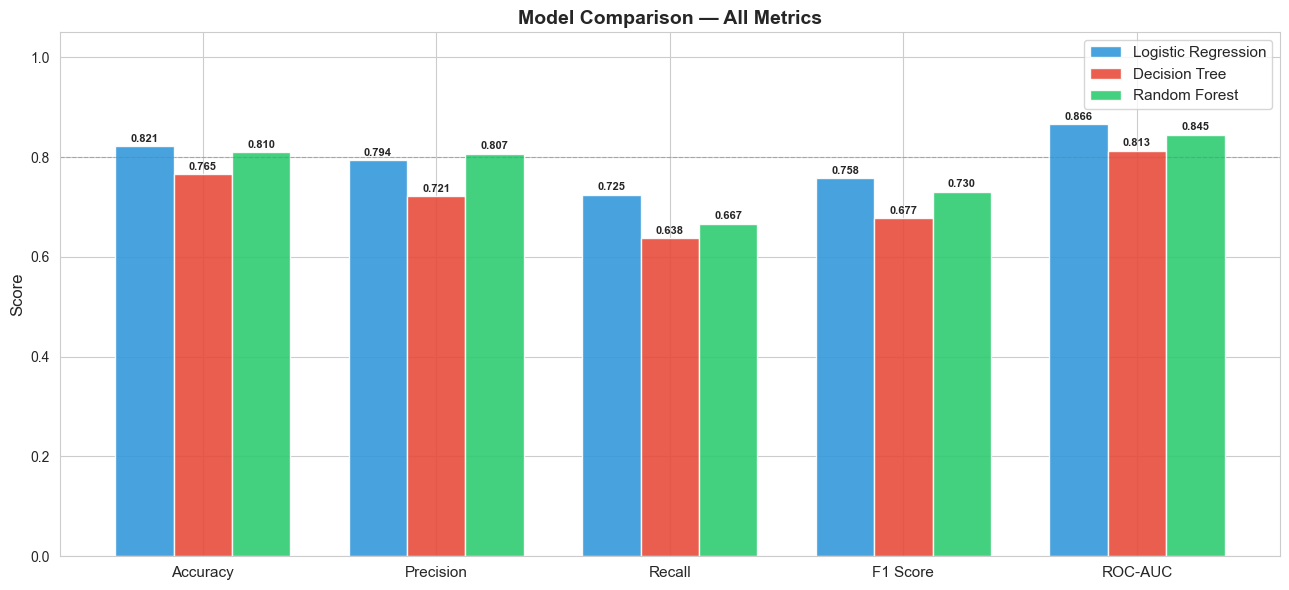

In [11]:
COLORS = {
    'Logistic Regression': '#3498db',
    'Decision Tree':       '#e74c3c',
    'Random Forest':       '#2ecc71'
}
metric_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metric_list))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, name in enumerate(models):
    vals = [results[name][m] for m in metric_list]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=COLORS[name], edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metric_list, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

### 6.2 Confusion Matrices

Each cell shows: **True Negatives** (top-left), **False Positives** (top-right), **False Negatives** (bottom-left), **True Positives** (bottom-right).

A false negative (predicting someone didn't survive when they did) is arguably the more costly error in a humanitarian context.

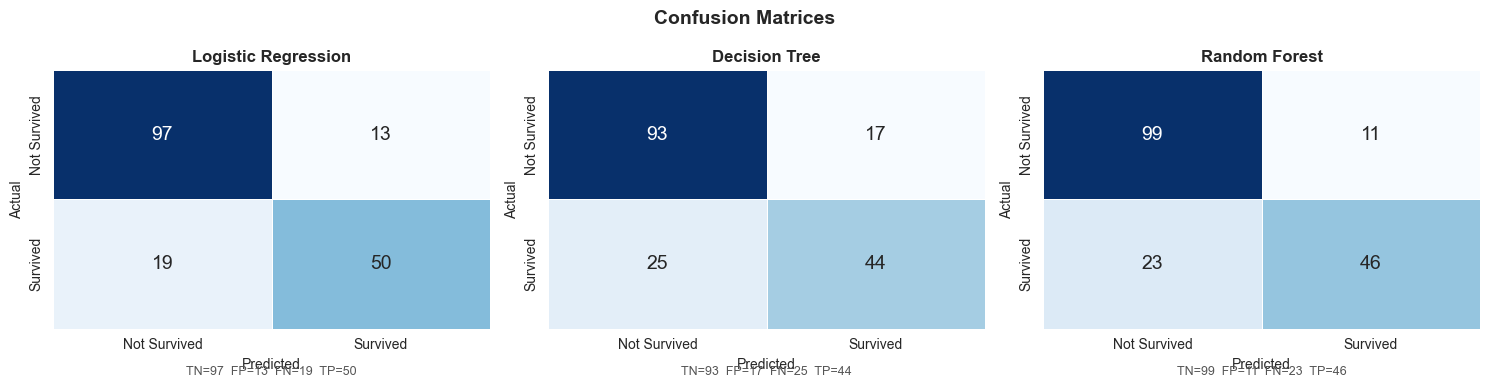

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'],
                linewidths=0.5, cbar=False, annot_kws={'size': 14})
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.18, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
            ha='center', transform=ax.transAxes, fontsize=9, color='#555')

plt.tight_layout()
plt.show()

### 6.3 ROC Curves

The ROC curve shows the trade-off between True Positive Rate and False Positive Rate across every possible classification threshold. AUC (Area Under the Curve) summarises this in one number - 1.0 is perfect, 0.5 is random. A higher AUC means the model is better at ranking survivors above non-survivors regardless of the threshold chosen.

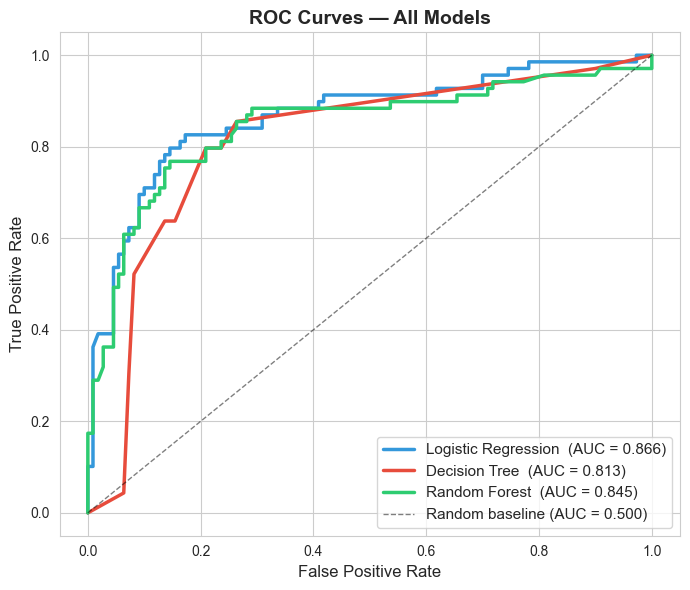

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))

for name in models:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})',
            color=COLORS[name], linewidth=2.5)

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random baseline (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 6.4 Cross-Validation F1 Scores

5-fold stratified cross-validation trains and evaluates each model 5 times on different data splits. The mean gives a more reliable performance estimate than a single train/test split, and the standard deviation tells us how stable the model is across different data subsets. A lower std is better - it means the model generalises consistently rather than being sensitive to which data it sees.

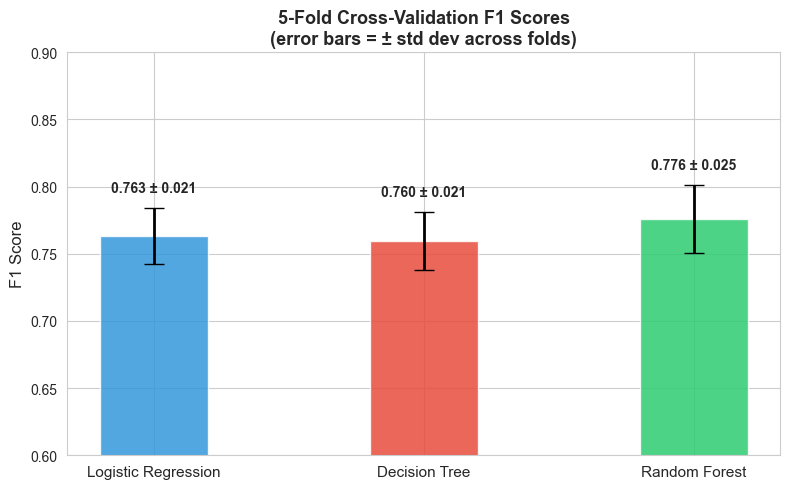

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, name in enumerate(models):
    cv_scores = cross_val_score(models[name], X, y, cv=cv, scoring='f1')
    ax.bar(i, cv_scores.mean(), color=COLORS[name], edgecolor='white',
           alpha=0.85, width=0.4)
    ax.errorbar(i, cv_scores.mean(), yerr=cv_scores.std(),
                fmt='none', color='black', capsize=7, linewidth=2)
    ax.text(i, cv_scores.mean() + cv_scores.std() + 0.012,
            f'{cv_scores.mean():.3f} ± {cv_scores.std():.3f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(list(models.keys()), fontsize=11)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation F1 Scores\n(error bars = ± std dev across folds)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.6, 0.9)
plt.tight_layout()
plt.show()

### 6.5 Feature Importance & Logistic Regression Coefficients

Two complementary views of what the models learned:
- **Random Forest importance** = how much each feature reduced impurity across all 100 trees
- **Logistic Regression coefficients** = direction and magnitude of each feature's effect on survival log-odds (blue = increases survival probability, red = decreases it)

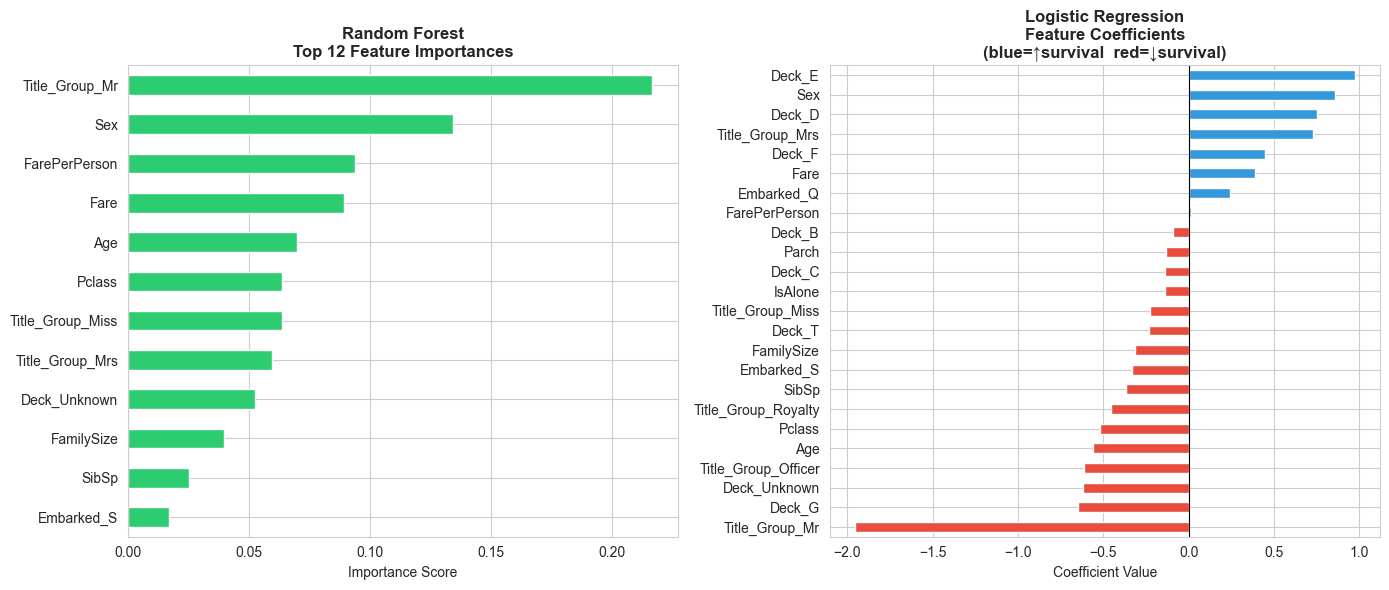

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest importances
rf = results['Random Forest']['model']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(12)
feat_imp.plot(kind='barh', ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_title('Random Forest\nTop 12 Feature Importances', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# LR coefficients
lr = results['Logistic Regression']['model']
coef = pd.Series(lr.coef_[0], index=X.columns).sort_values()
bar_colors = ['#e74c3c' if c < 0 else '#3498db' for c in coef]
coef.plot(kind='barh', ax=axes[1], color=bar_colors, edgecolor='white')
axes[1].set_title('Logistic Regression\nFeature Coefficients\n(blue=↑survival  red=↓survival)',
                  fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 7. Best Model Selection & Explanation

### Winner: Logistic Regression

| Metric | Logistic Regression | Decision Tree | Random Forest |
|--------|--------------------:|-------------:|-------------:|
| Accuracy | **0.8212** | 0.7654 | 0.8101 |
| Precision | 0.7937 | 0.7213 | **0.8070** |
| Recall | **0.7246** | 0.6377 | 0.6667 |
| F1 Score | **0.7576** | 0.6769 | 0.7302 |
| ROC-AUC | **0.8661** | 0.8129 | 0.8452 |
| CV F1 Mean | 0.7633 | 0.7595 | **0.7760** |
| CV F1 Std | **±0.021** | ±0.021 | ±0.025 |

**Logistic Regression wins on four of six metrics.** Here's the reasoning:

**1. Highest F1 Score (0.758)** - The primary metric given the class imbalance. Logistic Regression achieves the best balance between precision and recall. Random Forest has slightly higher precision (0.807 vs 0.794) but at a significant recall cost (0.667 vs 0.725), meaning it misses far more actual survivors.

**2. Highest ROC-AUC (0.866)** - It is the best at ranking survivors above non-survivors across all possible thresholds, not just the default 0.5. This is the most robust measure of discrimination ability.

**3. Most stable (CV Std ±0.021)** - Cross-validation shows that Logistic Regression and Decision Tree are equally stable, while Random Forest has slightly higher variance across folds (±0.025) despite its ensemble nature, possibly due to the small dataset size (891 rows).

**4. Decision Tree is clearly the weakest model** - Lowest accuracy, lowest F1, and lowest ROC-AUC. Even with `max_depth=5`, the single-tree approach generalises worse than either of the other two. Its performance drop vs Random Forest (0.677 vs 0.730 F1) illustrates exactly what bagging is designed to fix.

**Why not Random Forest?** It has the highest CV F1 mean (0.776) and highest precision, but its recall (0.667) is notably lower than Logistic Regression (0.725). In survival prediction, missing real survivors (false negatives) is costly. Its ROC-AUC is also 2 percentage points lower than Logistic Regression. For a dataset of this size, the additional complexity of 100 trees doesn't pay off.

**What the models learned:** Both top models agree that `Sex` (being female), high `FarePerPerson`, and the `Title_Group_Mrs`/`Title_Group_Miss` flags are the strongest positive predictors of survival — consistent with the historical "women and children first" evacuation policy. Being male (`Title_Group_Mr`) is the strongest negative predictor in both models.

In [17]:
# Final summary printout
print("   FINAL MODEL COMPARISON SUMMARY")
for name in models:
    r = results[name]
    print(f"\n{name}:")
    print(f"  Accuracy : {r['Accuracy']:.4f}")
    print(f"  Precision: {r['Precision']:.4f}")
    print(f"  Recall   : {r['Recall']:.4f}")
    print(f"  F1 Score : {r['F1 Score']:.4f}")
    print(f"  ROC-AUC  : {r['ROC-AUC']:.4f}")
    print(f"  CV F1    : {r['CV F1 Mean']:.4f} ± {r['CV F1 Std']:.4f}")
print("  BEST MODEL: Logistic Regression")
print("  REASON: Highest F1 (0.758) + ROC-AUC (0.866),")
print("          best recall, and most stable CV scores")

   FINAL MODEL COMPARISON SUMMARY

Logistic Regression:
  Accuracy : 0.8212
  Precision: 0.7937
  Recall   : 0.7246
  F1 Score : 0.7576
  ROC-AUC  : 0.8661
  CV F1    : 0.7633 ± 0.0206

Decision Tree:
  Accuracy : 0.7654
  Precision: 0.7213
  Recall   : 0.6377
  F1 Score : 0.6769
  ROC-AUC  : 0.8129
  CV F1    : 0.7595 ± 0.0214

Random Forest:
  Accuracy : 0.8101
  Precision: 0.8070
  Recall   : 0.6667
  F1 Score : 0.7302
  ROC-AUC  : 0.8452
  CV F1    : 0.7760 ± 0.0252
  BEST MODEL: Logistic Regression
  REASON: Highest F1 (0.758) + ROC-AUC (0.866),
          best recall, and most stable CV scores
